<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  7.63MB/s    in 32s     
2026-08-30 01:04:35 (6.26 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [83]:
# Let's create a dataframe for the required columns for the visualizations
QUERY = """
SELECT CompTotal, Age, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
      AND CompTotal IS NOT NULL
      AND JobSatPoints_6 IS NOT NULL 
"""

df = pd.read_sql_query(QUERY, conn)

df.head()

,CompTotal,Age,JobSatPoints_6
0,2040000.0,18-24 years old,65.0
1,85000.0,35-44 years old,0.0
2,110000.0,25-34 years old,20.0
3,126420.0,35-44 years old,30.0
4,195000.0,45-54 years old,30.0


In [84]:
# Now let's see some stats about the column
df["CompTotal"].describe()

count     2.247800e+04
mean     4.448794e+145
std      6.669928e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.520000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

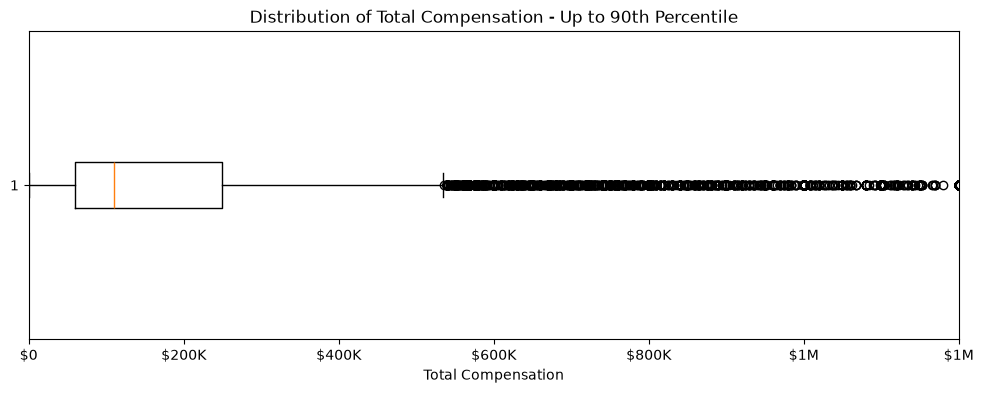

In [31]:
# Let's create our first boxplot
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

upper_limit = df_comp["CompTotal"].quantile(0.90)

plt.figure(figsize=(12, 4))

plt.boxplot(
    df["CompTotal"],
     orientation="horizontal"
)

plt.xlim(0, upper_limit)

plt.title("Distribution of Total Compensation - Up to 90th Percentile")
plt.xlabel("Total Compensation")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [32]:
# Let's check Age categories
df["Age"].value_counts()

Age
25-34 years old       14657
35-44 years old        9352
18-24 years old        4636
45-54 years old        3516
55-64 years old        1279
65 years or older       196
Under 18 years old       90
Prefer not to say        14
Name: count, dtype: int64

In [33]:
# Let's map Age for a numerical categorial as we've done in previous assignments
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df["AgeNumeric"] = df["Age"].map(age_mapping)

# Checking the converted values
df[["Age", "AgeNumeric"]].drop_duplicates().sort_values("AgeNumeric")

,Age,AgeNumeric
559,Under 18 years old,17.0
0,18-24 years old,21.0
1,25-34 years old,29.5
2,35-44 years old,39.5
6,45-54 years old,49.5
9,55-64 years old,59.5
61,65 years or older,65.0
1426,Prefer not to say,NaN


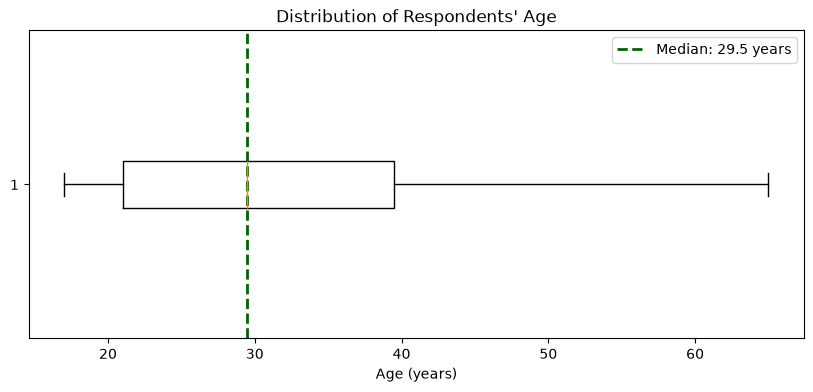

In [34]:
# Let's visualize the boxsplot removing missing values
median_age = df["AgeNumeric"].median()

plt.figure(figsize=(10, 4))

plt.boxplot(
    df_age["AgeNumeric"].dropna(),
    orientation="horizontal"
)

plt.axvline(
    median_age,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_age:.1f} years"
)

plt.title("Distribution of Respondents' Age")
plt.xlabel("Age (years)")
plt.legend()

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [40]:
# Let's create a new Column to better visualize AgeGroups
age_mapping = {
    "Under 18 years old": "Under 25",
    "18-24 years old": "Under 25",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55+",
    "65 years or older": "55+"
}

df["AgeGroup"] = df["Age"].map(age_mapping)
df["AgeGroup"].value_counts()

AgeGroup
25-34       14657
35-44        9352
Under 25     4726
45-54        3516
55+          1475
Name: count, dtype: int64

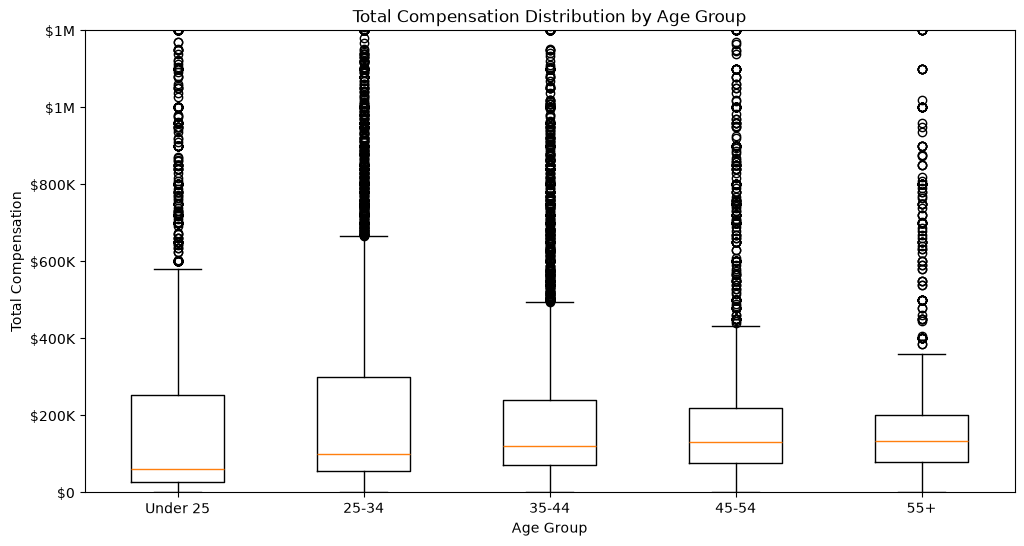

In [52]:
# Visualizing the boxsplot Grouped by Age
upper_limit = df["CompTotal"].quantile(0.90)

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=age_groups
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [55]:
# Checking JobSatPoints_6 column
df["JobSatPoints_6"].value_counts().sort_index()

JobSatPoints_6
0.0      5252
1.0        32
2.0        38
3.0        28
4.0        18
         ... 
96.0        1
97.0        1
98.0        2
99.0       14
100.0     740
Name: count, Length: 90, dtype: int64

In [63]:
# Let's create a boxplot_data group by level if satisfaction
job_sat_levels = sorted(
    df["JobSatPoints_6"].unique()
)

boxplot_data = [
    df.loc[
        df["JobSatPoints_6"] == level,
        "CompTotal"
    ]
    for level in job_sat_levels
]

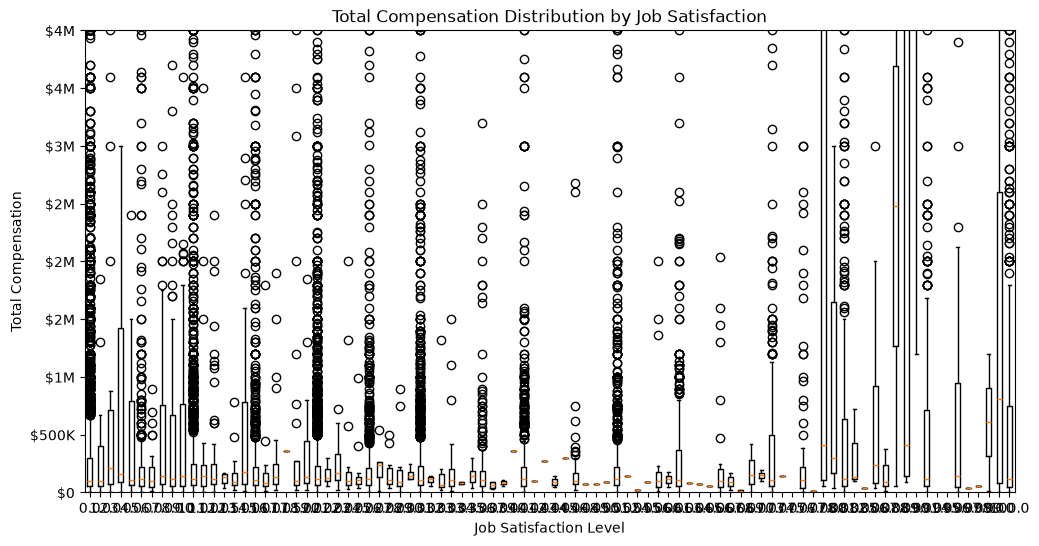

In [65]:
# Visualizing boxplot
upper_limit = df_jobsat["CompTotal"].quantile(0.95)

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=job_sat_levels
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

In [66]:
# For a better visualization let's create groups of satisfaction and visualize per group
bins = [0, 20, 40, 60, 80, 100]

labels = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

df["JobSatGroup"] = pd.cut(
    df["JobSatPoints_6"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["JobSatGroup"].value_counts().sort_index()

JobSatGroup
0–20      13897
21–40      4586
41–60      1517
61–80      1126
81–100     1352
Name: count, dtype: int64

In [67]:
# let's create a boxplot data based on this new groups
job_sat_groups = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

boxplot_data = [
    df.loc[
        df["JobSatGroup"] == group,
        "CompTotal"
    ]
    for group in job_sat_groups
]

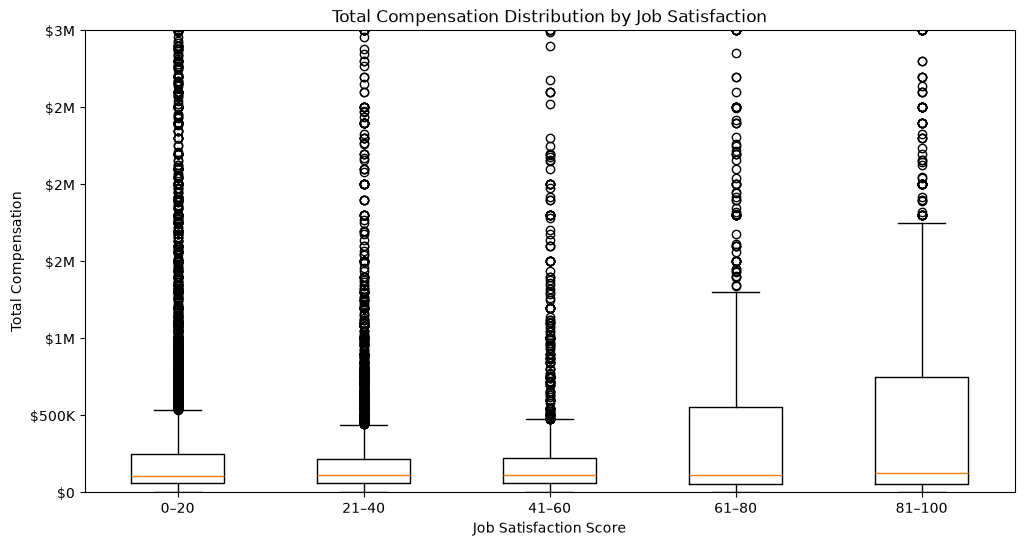

In [70]:
# And visualize the new boxplot per JobSatGroup
upper_limit = df_jobsat["CompTotal"].quantile(0.94)

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=job_sat_groups
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution by Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [71]:
# Let's create a new dataframe with this required columns
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
  AND ConvertedCompYearly IS NOT NULL
"""

df_dev = pd.read_sql_query(QUERY, conn)

In [74]:
# Let's check DevTypes
df_dev["DevType"].unique()

<ArrowStringArray>
['Data scientist or machine learning specialist',
                           'Academic researcher',
                           'Developer, back-end',
                                       'Student',
                           'Engineering manager',
                       'Other (please specify):',
                         'Developer, full-stack',
                          'Developer, front-end',
   'Developer, embedded applications or devices',
                    'Engineer, site reliability',
                             'Developer, mobile',
                   'Developer, game or graphics',
          'Senior Executive (C-Suite, VP, etc.)',
                         'Developer, QA or test',
                      'Data or business analyst',
                          'System administrator',
                 'Cloud infrastructure engineer',
 'Developer, desktop or enterprise applications',
                   'Research & Development role',
                         'Secur

In [75]:
# Let's check the top 5 developers type
dev_type_counts = df_dev["DevType"].value_counts()

top_5_dev_types = dev_type_counts.head(5)

print(top_5_dev_types)

DevType
Developer, full-stack                            8290
Developer, back-end                              4738
Developer, front-end                             1412
Developer, desktop or enterprise applications    1061
Developer, mobile                                 825
Name: count, dtype: int64

In [76]:
# Let's create a boxplot data for the chart
top_5 = top_5_dev_types.index.tolist()

boxplot_data = [
    df_dev.loc[
        df_dev["DevType"] == role,
        "ConvertedCompYearly"
    ]
    for role in top_5
]

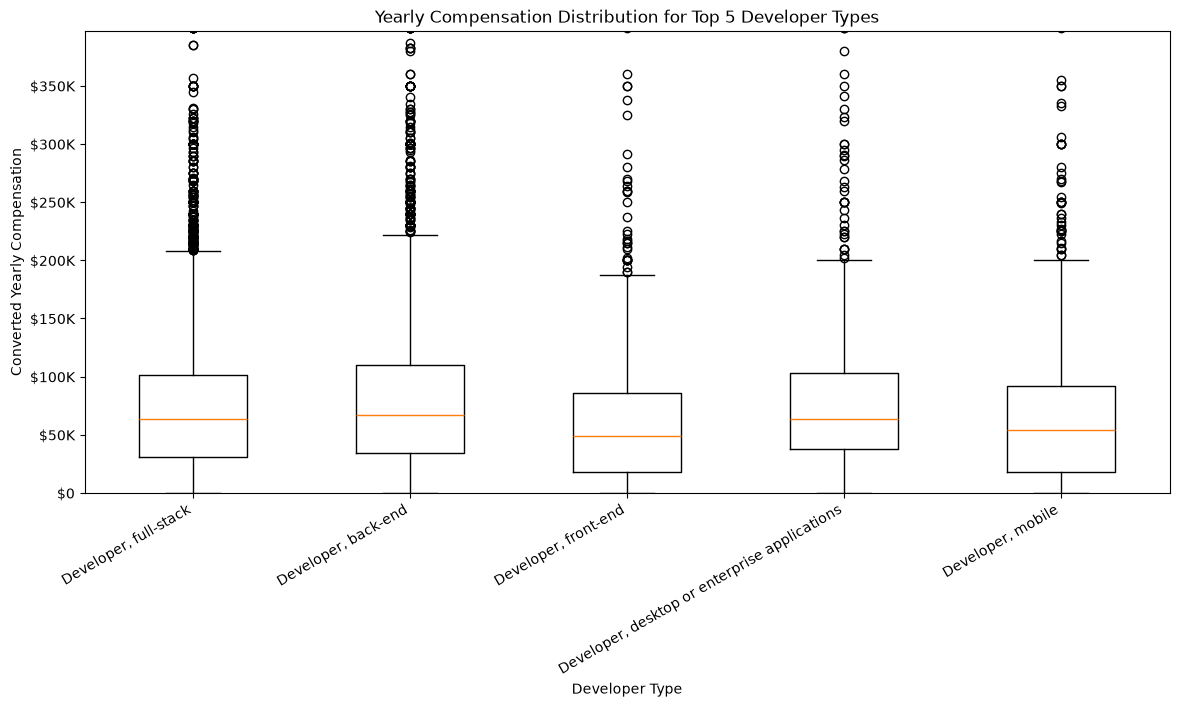

In [80]:
# Visualizing boxplot
upper_limit = df_dev["ConvertedCompYearly"].quantile(0.99)

plt.figure(figsize=(14, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=top_5
)

plt.ylim(0, upper_limit)

plt.title("Yearly Compensation Distribution for Top 5 Developer Types")
plt.xlabel("Developer Type")
plt.ylabel("Converted Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.xticks(rotation=30, ha="right")

plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [85]:
# Let's create a new dataframe with both columns
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
  AND CompTotal IS NOT NULL
"""

df_country = pd.read_sql_query(QUERY, conn)

df_country["CompTotal"] = pd.to_numeric(
    df_country["CompTotal"],
    errors="coerce"
)

df_country = df_country.dropna(
    subset=["Country", "CompTotal"]
)

In [86]:
# Let's find the top 5 countries
country_counts = df_country["Country"].value_counts()

top_5_countries = country_counts.head(5)

top_5_countries

Country
United States of America                                7042
Germany                                                 3004
United Kingdom of Great Britain and Northern Ireland    2008
Ukraine                                                 1610
India                                                   1551
Name: count, dtype: int64

In [87]:
# Now let's create the boxplot data
top_5 = top_5_countries.index.tolist()

boxplot_data = [
    df_country.loc[
        df_country["Country"] == country,
        "CompTotal"
    ]
    for country in top_5
]

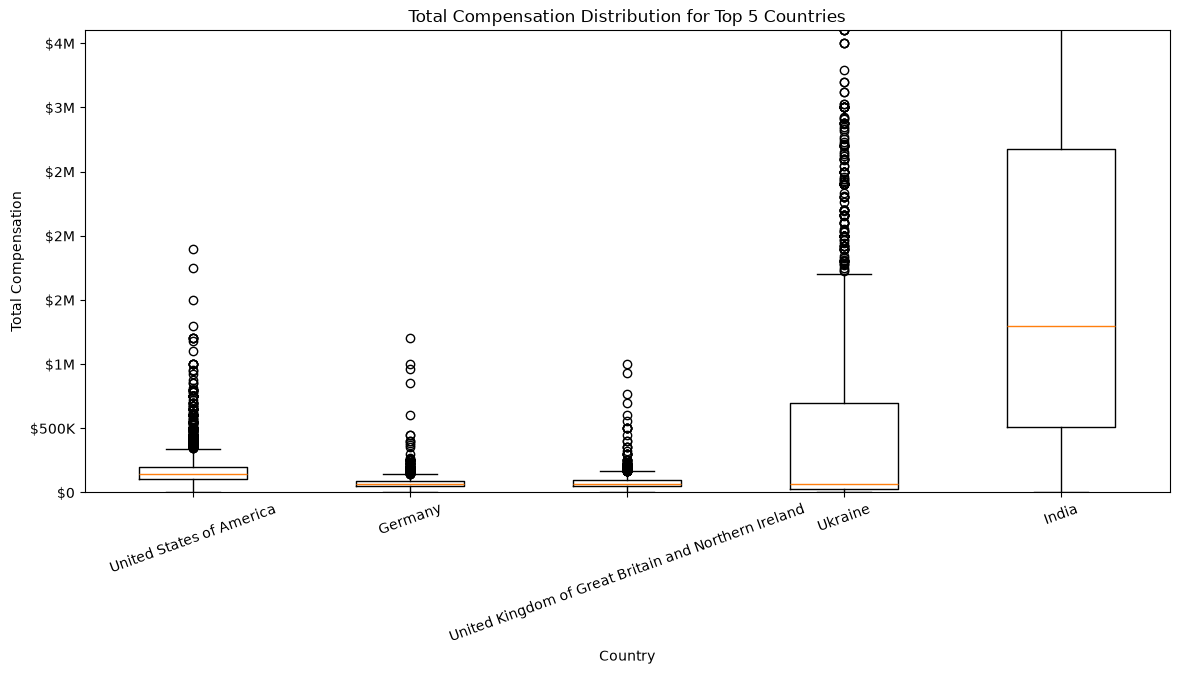

In [89]:
# And visualize our boxplot 
upper_limit = df_country["CompTotal"].quantile(0.95)

plt.figure(figsize=(14, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=top_5
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution for Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.xticks(rotation=20)

plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [90]:
# Let's create a new dataframa with the required columns
QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
  AND CompTotal IS NOT NULL
"""

df_employment = pd.read_sql_query(QUERY, conn)

df_employment["CompTotal"] = pd.to_numeric(
    df_employment["CompTotal"],
    errors="coerce"
)

df_employment = df_employment.dropna(
    subset=["Employment", "CompTotal"]
)

In [91]:
# Let's check employment types
employment_counts = df_employment["Employment"].value_counts()

print(employment_counts)

Employment
Employed, full-time                                                                                                               25309
Independent contractor, freelancer, or self-employed                                                                               2470
Employed, full-time;Independent contractor, freelancer, or self-employed                                                           2424
Employed, part-time                                                                                                                 624
Employed, full-time;Student, part-time                                                                                              525
                                                                                                                                  ...  
Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Employed, part-time        1
Independent contractor, freelancer, o

In [93]:
# Let's split in indivisual employment types
employment_counts = (
    df_employment["Employment"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

employment_counts.head(10)

Employment
Employed, full-time                                     29231
Independent contractor, freelancer, or self-employed     5816
Employed, part-time                                      2005
Student, full-time                                       1191
Student, part-time                                       1028
Not employed, but looking for work                        237
Retired                                                    40
Not employed, and not looking for work                     40
Name: count, dtype: int64

In [95]:
# Now let's select the top employment types
top_5_employment = employment_counts.head(5)

top_5_employment

Employment
Employed, full-time                                     29231
Independent contractor, freelancer, or self-employed     5816
Employed, part-time                                      2005
Student, full-time                                       1191
Student, part-time                                       1028
Name: count, dtype: int64

In [97]:
# Create ou boxplot data
employment_types = top_5_employment.index.tolist()

boxplot_data = [
    df_employment.loc[
        df_employment["Employment"].str.split(";").apply(
            lambda x: employment_type in [item.strip() for item in x]
        ),
        "CompTotal"
    ]
    for employment_type in employment_types
]

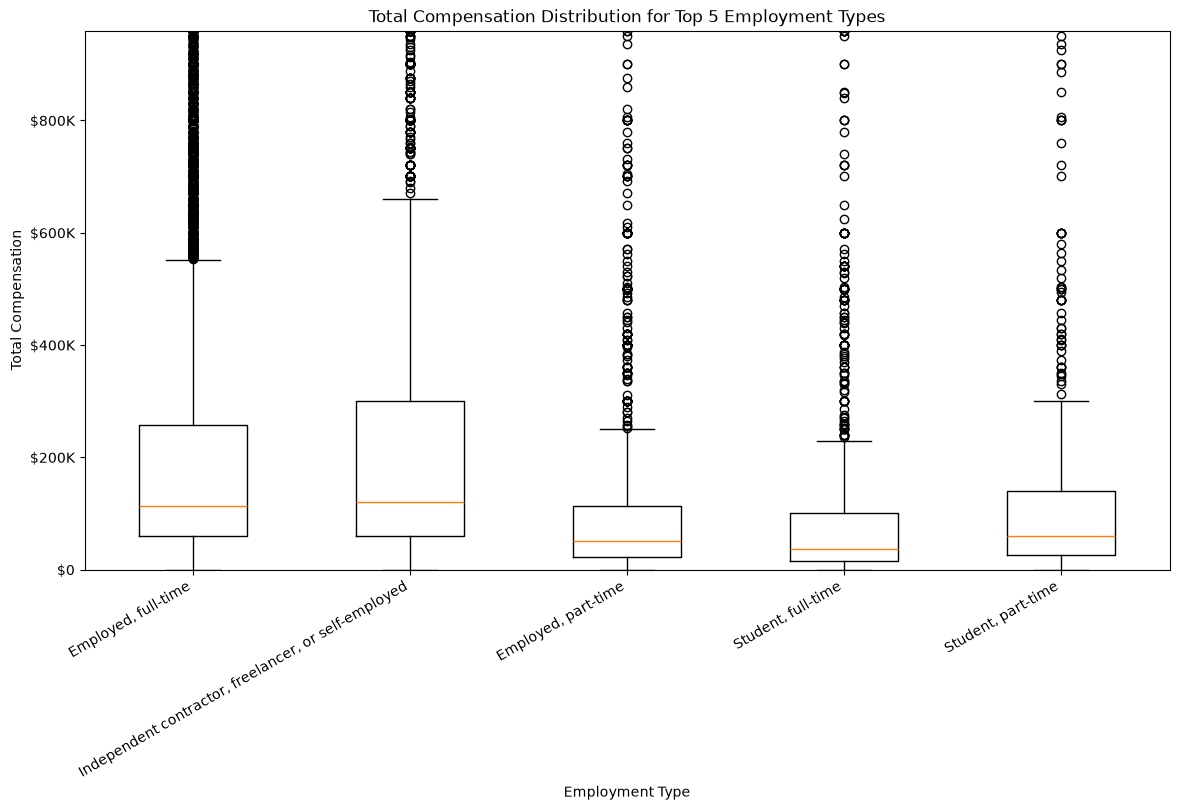

In [101]:
# And visualize our boxplot 
upper_limit = df_employment["CompTotal"].quantile(0.88)

plt.figure(figsize=(14, 7))

plt.boxplot(
    boxplot_data,
    tick_labels=employment_types
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution for Top 5 Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.xticks(rotation=30, ha="right")

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [102]:
# Let's create a new daframe for the columns
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSatPoints_6 IS NOT NULL
"""

df_jobsat = pd.read_sql_query(QUERY, conn)

In [103]:
# Convert YearsCodePro to numeric
years_mapping = {
    "Less than 1 year": 0.5,
    "More than 50 years": 51
}

df_jobsat["YearsCodePro"] = df_jobsat["YearsCodePro"].replace(
    years_mapping
)

df_jobsat["YearsCodePro"] = pd.to_numeric(
    df_jobsat["YearsCodePro"],
    errors="coerce"
)

In [104]:
# And remove values that couldn't be converted
df_jobsat = df_jobsat.dropna(
    subset=["YearsCodePro", "JobSatPoints_6"]
)

In [105]:
# Let's check the JobSat scale 
print(df_jobsat["JobSatPoints_6"].min())
print(df_jobsat["JobSatPoints_6"].max())

0.0
100.0

In [106]:
# And create a new JobSatGroup for this dataset
bins = [0, 20, 40, 60, 80, 100]

labels = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

df_jobsat["JobSatGroup"] = pd.cut(
    df_jobsat["JobSatPoints_6"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [111]:
# Now we preapare the boxplot data
job_sat_groups = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

boxplot_data = [
    df_jobsat.loc[
        df_jobsat["JobSatGroup"] == group,
        "YearsCodePro"
    ]
    for group in job_sat_groups
]

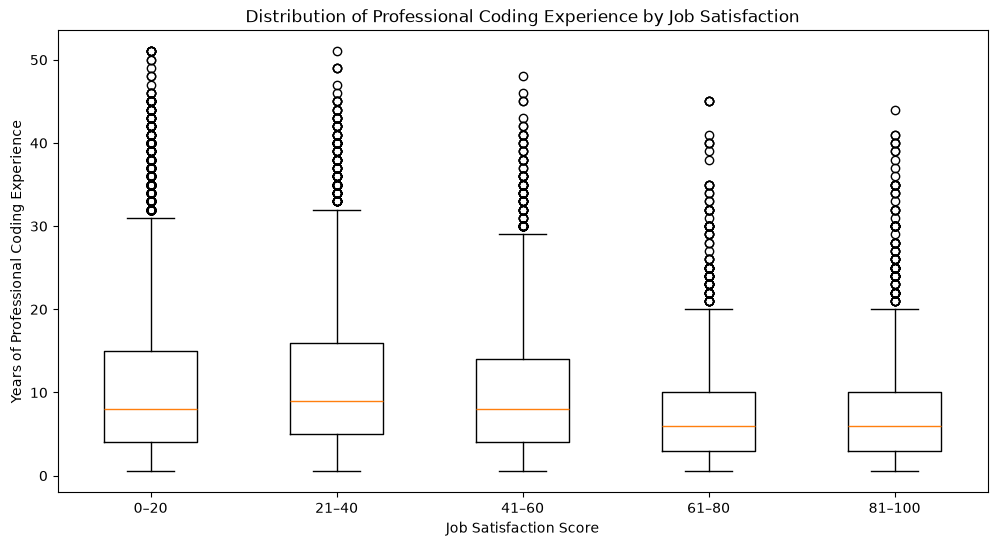

In [110]:
# And visualize our boxplot
plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=job_sat_groups
)

plt.title(
    "Distribution of Professional Coding Experience by Job Satisfaction"
)

plt.xlabel("Job Satisfaction Score")
plt.ylabel("Years of Professional Coding Experience")

plt.show()%alias

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.


<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  7.63MB/s    in 32s     
2026-08-30 01:04:35 (6.26 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [83]:
# Let's create a dataframe for the required columns for the visualizations
QUERY = """
SELECT CompTotal, Age, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
      AND CompTotal IS NOT NULL
      AND JobSatPoints_6 IS NOT NULL 
"""

df = pd.read_sql_query(QUERY, conn)

df.head()

,CompTotal,Age,JobSatPoints_6
0,2040000.0,18-24 years old,65.0
1,85000.0,35-44 years old,0.0
2,110000.0,25-34 years old,20.0
3,126420.0,35-44 years old,30.0
4,195000.0,45-54 years old,30.0


In [84]:
# Now let's see some stats about the column
df["CompTotal"].describe()

count     2.247800e+04
mean     4.448794e+145
std      6.669928e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.520000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

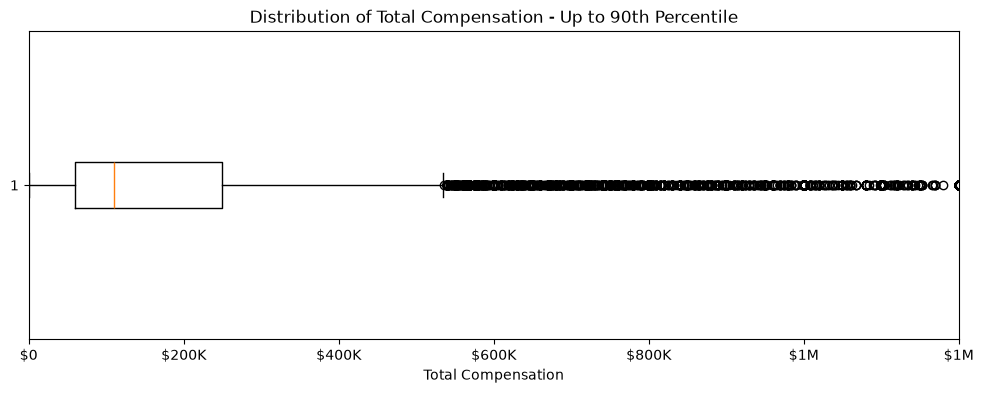

In [31]:
# Let's create our first boxplot
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

upper_limit = df_comp["CompTotal"].quantile(0.90)

plt.figure(figsize=(12, 4))

plt.boxplot(
    df["CompTotal"],
     orientation="horizontal"
)

plt.xlim(0, upper_limit)

plt.title("Distribution of Total Compensation - Up to 90th Percentile")
plt.xlabel("Total Compensation")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [32]:
# Let's check Age categories
df["Age"].value_counts()

Age
25-34 years old       14657
35-44 years old        9352
18-24 years old        4636
45-54 years old        3516
55-64 years old        1279
65 years or older       196
Under 18 years old       90
Prefer not to say        14
Name: count, dtype: int64

In [33]:
# Let's map Age for a numerical categorial as we've done in previous assignments
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df["AgeNumeric"] = df["Age"].map(age_mapping)

# Checking the converted values
df[["Age", "AgeNumeric"]].drop_duplicates().sort_values("AgeNumeric")

,Age,AgeNumeric
559,Under 18 years old,17.0
0,18-24 years old,21.0
1,25-34 years old,29.5
2,35-44 years old,39.5
6,45-54 years old,49.5
9,55-64 years old,59.5
61,65 years or older,65.0
1426,Prefer not to say,NaN


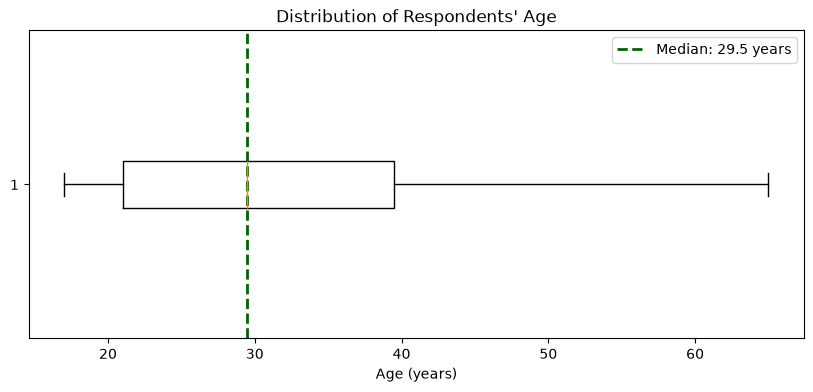

In [34]:
# Let's visualize the boxsplot removing missing values
median_age = df["AgeNumeric"].median()

plt.figure(figsize=(10, 4))

plt.boxplot(
    df_age["AgeNumeric"].dropna(),
    orientation="horizontal"
)

plt.axvline(
    median_age,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_age:.1f} years"
)

plt.title("Distribution of Respondents' Age")
plt.xlabel("Age (years)")
plt.legend()

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [40]:
# Let's create a new Column to better visualize AgeGroups
age_mapping = {
    "Under 18 years old": "Under 25",
    "18-24 years old": "Under 25",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55+",
    "65 years or older": "55+"
}

df["AgeGroup"] = df["Age"].map(age_mapping)
df["AgeGroup"].value_counts()

AgeGroup
25-34       14657
35-44        9352
Under 25     4726
45-54        3516
55+          1475
Name: count, dtype: int64

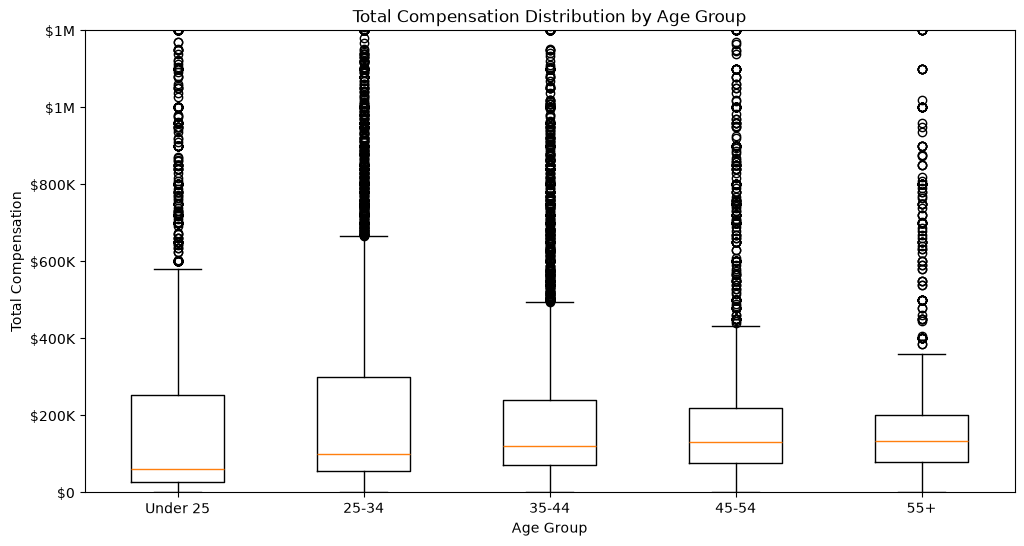

In [52]:
# Visualizing the boxsplot Grouped by Age
upper_limit = df["CompTotal"].quantile(0.90)

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=age_groups
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [55]:
# Checking JobSatPoints_6 column
df["JobSatPoints_6"].value_counts().sort_index()

JobSatPoints_6
0.0      5252
1.0        32
2.0        38
3.0        28
4.0        18
         ... 
96.0        1
97.0        1
98.0        2
99.0       14
100.0     740
Name: count, Length: 90, dtype: int64

In [63]:
# Let's create a boxplot_data group by level if satisfaction
job_sat_levels = sorted(
    df["JobSatPoints_6"].unique()
)

boxplot_data = [
    df.loc[
        df["JobSatPoints_6"] == level,
        "CompTotal"
    ]
    for level in job_sat_levels
]

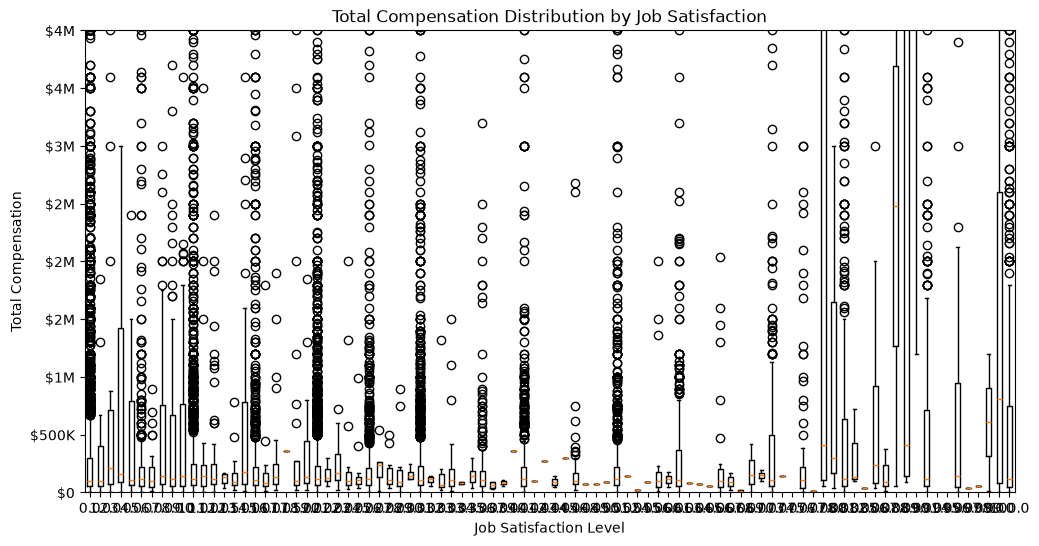

In [65]:
# Visualizing boxplot
upper_limit = df_jobsat["CompTotal"].quantile(0.95)

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=job_sat_levels
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

In [66]:
# For a better visualization let's create groups of satisfaction and visualize per group
bins = [0, 20, 40, 60, 80, 100]

labels = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

df["JobSatGroup"] = pd.cut(
    df["JobSatPoints_6"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["JobSatGroup"].value_counts().sort_index()

JobSatGroup
0–20      13897
21–40      4586
41–60      1517
61–80      1126
81–100     1352
Name: count, dtype: int64

In [67]:
# let's create a boxplot data based on this new groups
job_sat_groups = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

boxplot_data = [
    df.loc[
        df["JobSatGroup"] == group,
        "CompTotal"
    ]
    for group in job_sat_groups
]

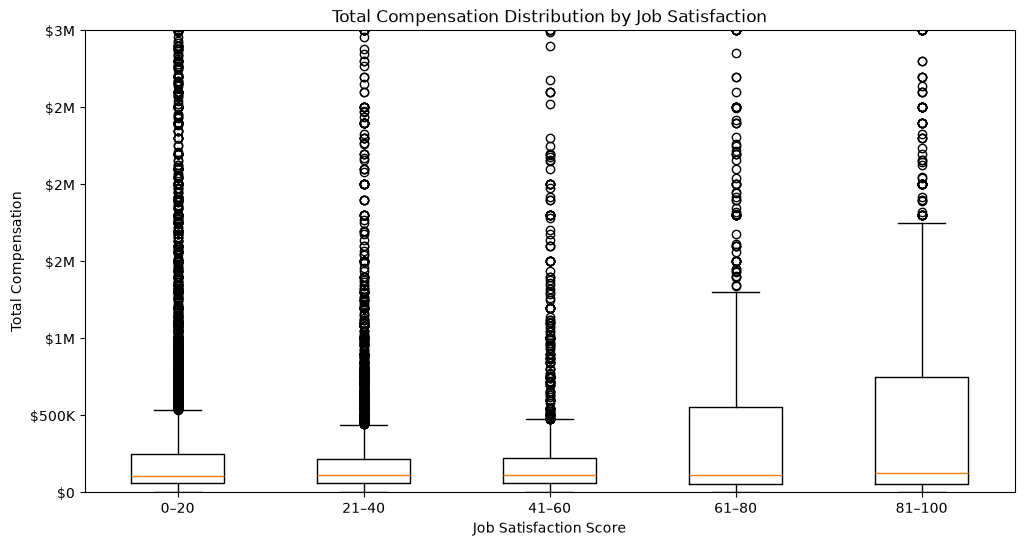

In [70]:
# And visualize the new boxplot per JobSatGroup
upper_limit = df_jobsat["CompTotal"].quantile(0.94)

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=job_sat_groups
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution by Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [71]:
# Let's create a new dataframe with this required columns
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
  AND ConvertedCompYearly IS NOT NULL
"""

df_dev = pd.read_sql_query(QUERY, conn)

In [74]:
# Let's check DevTypes
df_dev["DevType"].unique()

<ArrowStringArray>
['Data scientist or machine learning specialist',
                           'Academic researcher',
                           'Developer, back-end',
                                       'Student',
                           'Engineering manager',
                       'Other (please specify):',
                         'Developer, full-stack',
                          'Developer, front-end',
   'Developer, embedded applications or devices',
                    'Engineer, site reliability',
                             'Developer, mobile',
                   'Developer, game or graphics',
          'Senior Executive (C-Suite, VP, etc.)',
                         'Developer, QA or test',
                      'Data or business analyst',
                          'System administrator',
                 'Cloud infrastructure engineer',
 'Developer, desktop or enterprise applications',
                   'Research & Development role',
                         'Secur

In [75]:
# Let's check the top 5 developers type
dev_type_counts = df_dev["DevType"].value_counts()

top_5_dev_types = dev_type_counts.head(5)

print(top_5_dev_types)

DevType
Developer, full-stack                            8290
Developer, back-end                              4738
Developer, front-end                             1412
Developer, desktop or enterprise applications    1061
Developer, mobile                                 825
Name: count, dtype: int64

In [76]:
# Let's create a boxplot data for the chart
top_5 = top_5_dev_types.index.tolist()

boxplot_data = [
    df_dev.loc[
        df_dev["DevType"] == role,
        "ConvertedCompYearly"
    ]
    for role in top_5
]

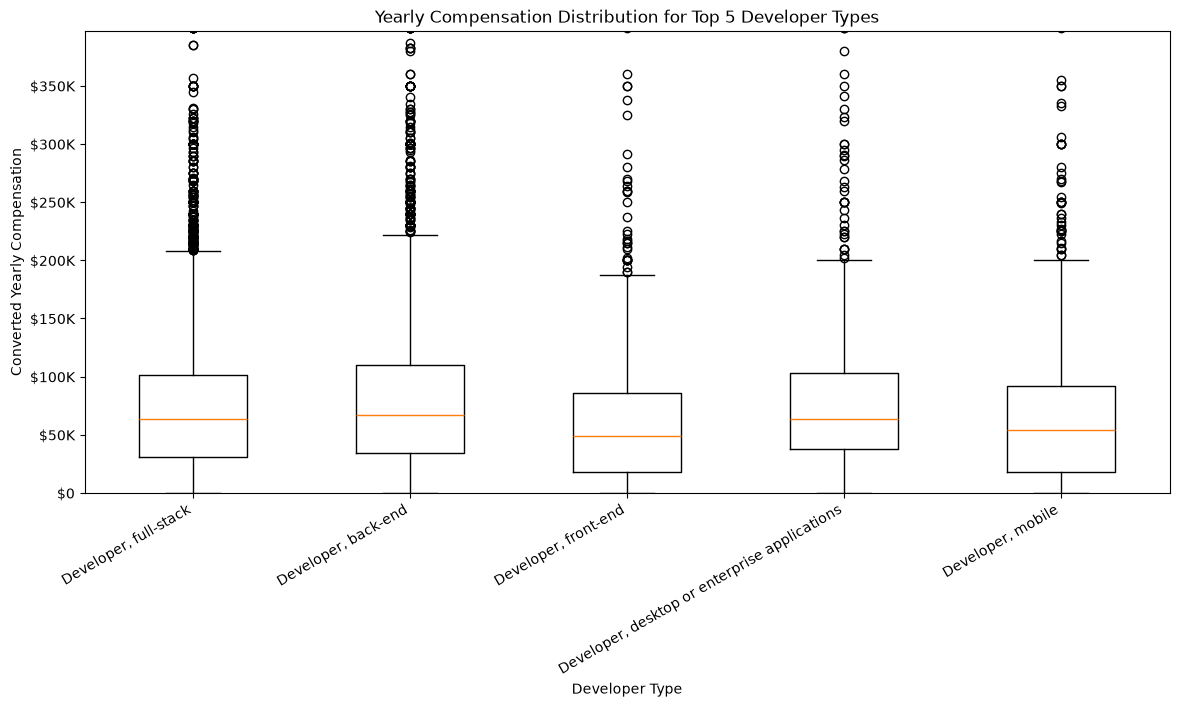

In [80]:
# Visualizing boxplot
upper_limit = df_dev["ConvertedCompYearly"].quantile(0.99)

plt.figure(figsize=(14, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=top_5
)

plt.ylim(0, upper_limit)

plt.title("Yearly Compensation Distribution for Top 5 Developer Types")
plt.xlabel("Developer Type")
plt.ylabel("Converted Yearly Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.xticks(rotation=30, ha="right")

plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [85]:
# Let's create a new dataframe with both columns
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
  AND CompTotal IS NOT NULL
"""

df_country = pd.read_sql_query(QUERY, conn)

df_country["CompTotal"] = pd.to_numeric(
    df_country["CompTotal"],
    errors="coerce"
)

df_country = df_country.dropna(
    subset=["Country", "CompTotal"]
)

In [86]:
# Let's find the top 5 countries
country_counts = df_country["Country"].value_counts()

top_5_countries = country_counts.head(5)

top_5_countries

Country
United States of America                                7042
Germany                                                 3004
United Kingdom of Great Britain and Northern Ireland    2008
Ukraine                                                 1610
India                                                   1551
Name: count, dtype: int64

In [87]:
# Now let's create the boxplot data
top_5 = top_5_countries.index.tolist()

boxplot_data = [
    df_country.loc[
        df_country["Country"] == country,
        "CompTotal"
    ]
    for country in top_5
]

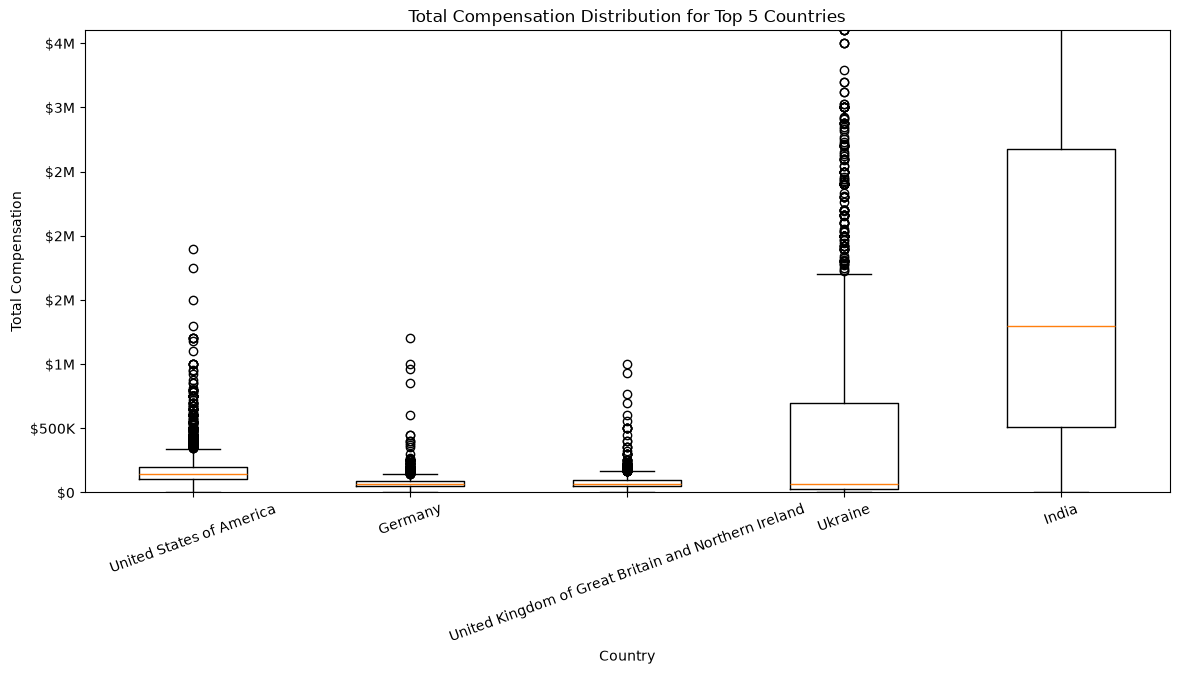

In [89]:
# And visualize our boxplot 
upper_limit = df_country["CompTotal"].quantile(0.95)

plt.figure(figsize=(14, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=top_5
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution for Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.xticks(rotation=20)

plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [90]:
# Let's create a new dataframa with the required columns
QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
  AND CompTotal IS NOT NULL
"""

df_employment = pd.read_sql_query(QUERY, conn)

df_employment["CompTotal"] = pd.to_numeric(
    df_employment["CompTotal"],
    errors="coerce"
)

df_employment = df_employment.dropna(
    subset=["Employment", "CompTotal"]
)

In [91]:
# Let's check employment types
employment_counts = df_employment["Employment"].value_counts()

print(employment_counts)

Employment
Employed, full-time                                                                                                               25309
Independent contractor, freelancer, or self-employed                                                                               2470
Employed, full-time;Independent contractor, freelancer, or self-employed                                                           2424
Employed, part-time                                                                                                                 624
Employed, full-time;Student, part-time                                                                                              525
                                                                                                                                  ...  
Student, full-time;Not employed, but looking for work;Independent contractor, freelancer, or self-employed;Employed, part-time        1
Independent contractor, freelancer, o

In [93]:
# Let's split in indivisual employment types
employment_counts = (
    df_employment["Employment"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

employment_counts.head(10)

Employment
Employed, full-time                                     29231
Independent contractor, freelancer, or self-employed     5816
Employed, part-time                                      2005
Student, full-time                                       1191
Student, part-time                                       1028
Not employed, but looking for work                        237
Retired                                                    40
Not employed, and not looking for work                     40
Name: count, dtype: int64

In [95]:
# Now let's select the top employment types
top_5_employment = employment_counts.head(5)

top_5_employment

Employment
Employed, full-time                                     29231
Independent contractor, freelancer, or self-employed     5816
Employed, part-time                                      2005
Student, full-time                                       1191
Student, part-time                                       1028
Name: count, dtype: int64

In [97]:
# Create ou boxplot data
employment_types = top_5_employment.index.tolist()

boxplot_data = [
    df_employment.loc[
        df_employment["Employment"].str.split(";").apply(
            lambda x: employment_type in [item.strip() for item in x]
        ),
        "CompTotal"
    ]
    for employment_type in employment_types
]

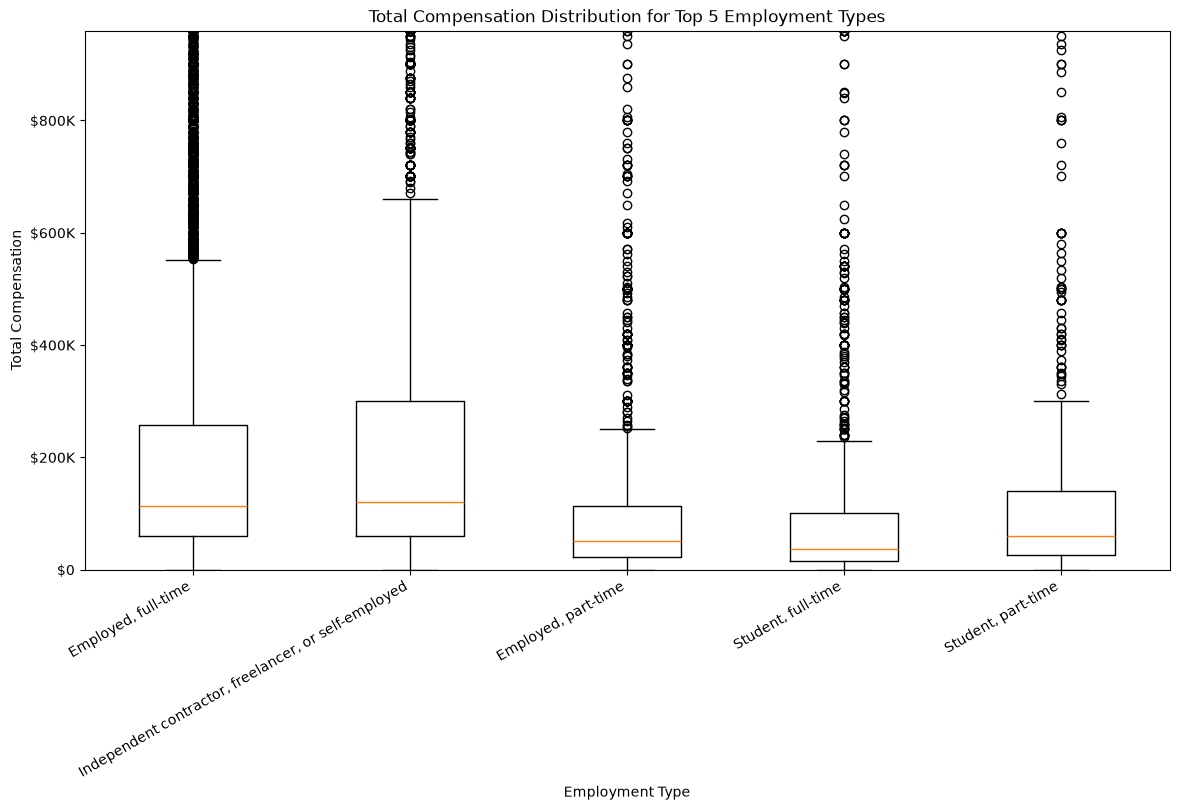

In [101]:
# And visualize our boxplot 
upper_limit = df_employment["CompTotal"].quantile(0.88)

plt.figure(figsize=(14, 7))

plt.boxplot(
    boxplot_data,
    tick_labels=employment_types
)

plt.ylim(0, upper_limit)

plt.title("Total Compensation Distribution for Top 5 Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.xticks(rotation=30, ha="right")

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [102]:
# Let's create a new daframe for the columns
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSatPoints_6 IS NOT NULL
"""

df_jobsat = pd.read_sql_query(QUERY, conn)

In [103]:
# Convert YearsCodePro to numeric
years_mapping = {
    "Less than 1 year": 0.5,
    "More than 50 years": 51
}

df_jobsat["YearsCodePro"] = df_jobsat["YearsCodePro"].replace(
    years_mapping
)

df_jobsat["YearsCodePro"] = pd.to_numeric(
    df_jobsat["YearsCodePro"],
    errors="coerce"
)

In [104]:
# And remove values that couldn't be converted
df_jobsat = df_jobsat.dropna(
    subset=["YearsCodePro", "JobSatPoints_6"]
)

In [105]:
# Let's check the JobSat scale 
print(df_jobsat["JobSatPoints_6"].min())
print(df_jobsat["JobSatPoints_6"].max())

0.0
100.0

In [106]:
# And create a new JobSatGroup for this dataset
bins = [0, 20, 40, 60, 80, 100]

labels = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

df_jobsat["JobSatGroup"] = pd.cut(
    df_jobsat["JobSatPoints_6"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [111]:
# Now we preapare the boxplot data
job_sat_groups = [
    "0–20",
    "21–40",
    "41–60",
    "61–80",
    "81–100"
]

boxplot_data = [
    df_jobsat.loc[
        df_jobsat["JobSatGroup"] == group,
        "YearsCodePro"
    ]
    for group in job_sat_groups
]

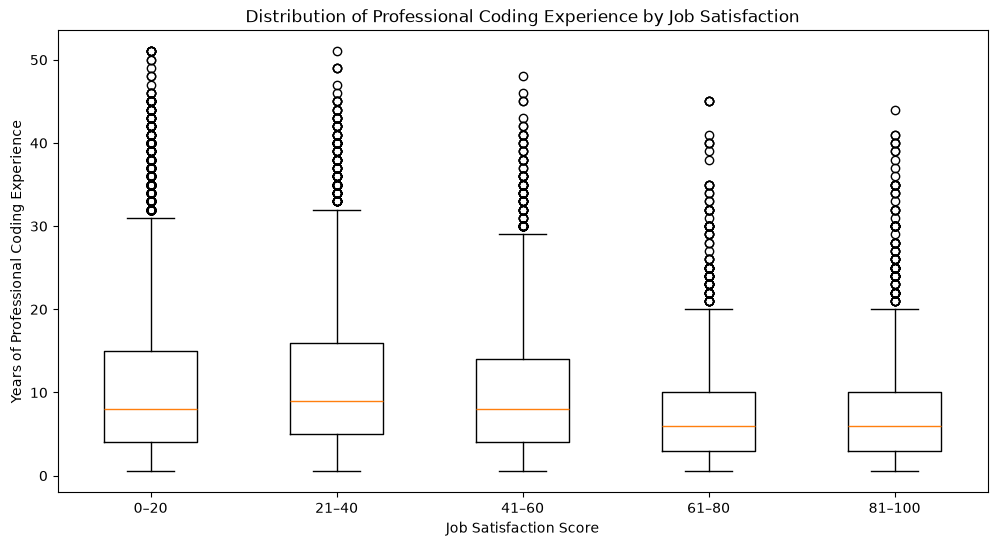

In [112]:
# And visualize our boxplot
plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=job_sat_groups
)

plt.title(
    "Distribution of Professional Coding Experience by Job Satisfaction"
)

plt.xlabel("Job Satisfaction Score")
plt.ylabel("Years of Professional Coding Experience")

plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [113]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
